## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

### Importing from files

In [2]:
import sys
import os

# Move up to the parent directory of 'notebookDir'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from axion_production.parameter_dependence import ParametersAxionMassDependence

## Initialization and Analysis of Axion Parameter Dependence

In this notebook, we analyze the dependence of parameters **A(m_a)**, **b(m_a)**, and **μ(m_a)** on axion mass **m_a** 
after selecting a specific axion production channel. The goal is to fit functions to describe these dependencies and evaluate their accuracy.

#### **Key Observations:**
1. **Polynomial Fit Behavior:**
   - The polynomial fits **A(log(m_a))**, **b(log(m_a))**, and **μ(log(m_a))** work well **within the provided mass range**:  
     **[0.623 eV, 6.23 eV]** (as given by Maxim's distribution data).  
   - However, **extrapolation beyond this range is highly unreliable**. The polynomial fit becomes unstable and produces unrealistic values.
2. **Function-Based Fit (Model-Driven Approach):**
   - Need to be developed.  

#### **Next Steps:**
- Validate function-based fits with alternative datasets.
- Investigate possible **physical constraints** that could guide extrapolation.
- Assess whether alternative parameterizations offer improved stability.

In [3]:
file_path = '../Maxim-data/Distributions_e_scat.dat'  # Set the correct file path
parameterDependence = ParametersAxionMassDependence("electron_scattering", file_path)

## Distribution: $f(q)\cdot q^3$

In [5]:
# --- DISTRIBUTION: f(q)*q^3 ---
distribution = "f(q)_q3"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -0.50  # -0.50
log_m_end = 2.00     # 2.00,
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 0.00418397 -0.02658969  0.06453845 -0.08082918  0.06259223 -0.00710414
 -0.04131934 -0.0176712  -0.00113516  0.04913227  0.08370138  1.05588445]
Polynomial fit coefficients for b: [ 0.0126411  -0.08106883  0.21457706 -0.3333029   0.31142509 -0.01752567
 -0.15017661 -0.10253075 -0.19366644 -0.16828299  1.93284802 -1.63665144]
Polynomial fit coefficients for μ: [  0.64515794  -4.92298668  14.83441461 -21.45246725  12.54409874
   4.27405498 -14.13100906  23.57031545 -43.24206414  64.1926413
 -66.76187893  32.41998749]


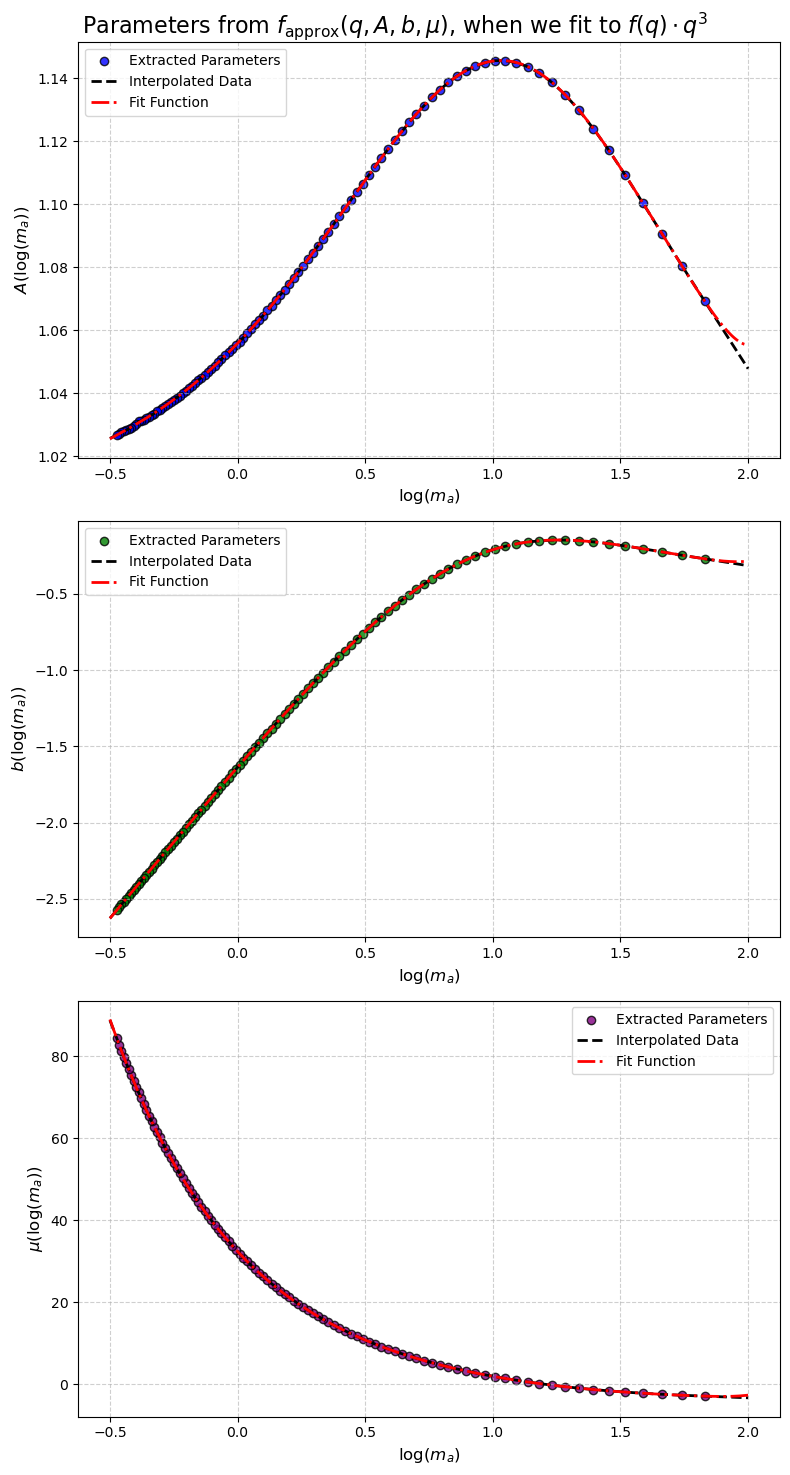

In [6]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^3$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(log_m_arr_input, points_param[i],
                color=colors[i], marker='o', edgecolors='black',
                alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    ax.plot(log_m_arr_set, interpolated_param[i],
             linestyle='--', linewidth=2, color='black',
             label='Interpolated Data')

    # Plot fitted function for the parameter
    ax.plot(log_m_arr_set, 
            parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                           log_m_arr_set,
                                                           "test_polynomial"),  # test_polynomial, test_fit
             linestyle='-.', linewidth=2, color='red',
             label='Fit Function')

    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)\cdot q^2$

In [7]:
# --- DISTRIBUTION: f(q)*q^2 ---
distribution = "f(q)_q2"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -0.50  # -0.50,
log_m_end = 2.00     # 2.00,
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 0.0035383  -0.02503782  0.0653189  -0.07672104  0.0429512  -0.00238132
 -0.0335174  -0.01275446  0.01400687  0.06706596  0.09648885  1.0728125 ]
Polynomial fit coefficients for b: [ 0.010543   -0.0714352   0.18477467 -0.24124334  0.18300898 -0.01600947
 -0.10237442 -0.08949019 -0.13277883 -0.08903787  1.98974311 -1.55175916]
Polynomial fit coefficients for μ: [ 3.71635723e-02 -3.33661219e-01  1.21017347e+00 -2.18797309e+00
  1.60459544e+00  1.90219403e+00 -9.39544670e+00  2.39183121e+01
 -4.72632563e+01  6.99410630e+01 -7.12933278e+01  3.59100592e+01]


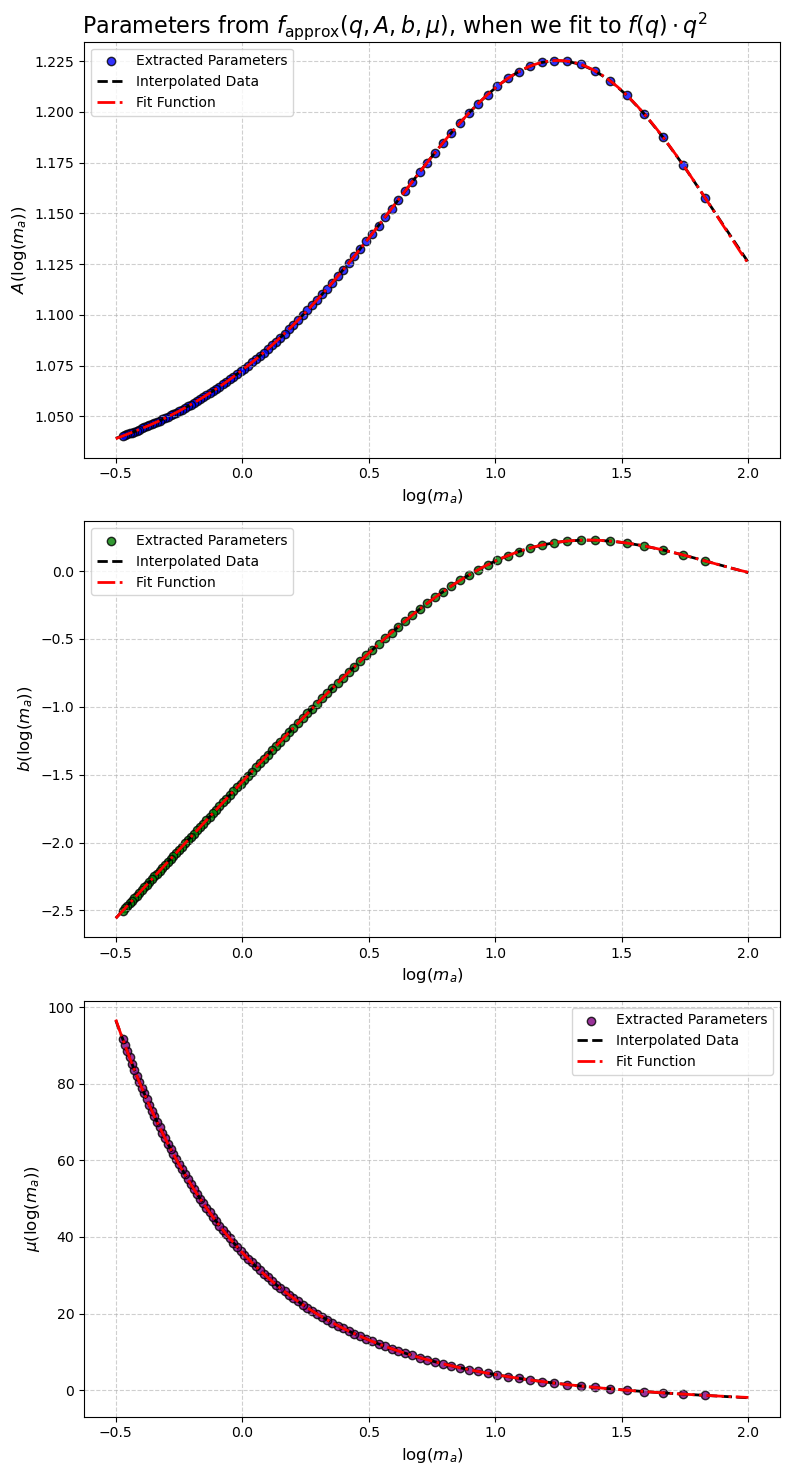

In [9]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q^2$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(log_m_arr_input, points_param[i],
                color=colors[i], marker='o', edgecolors='black',
                alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    ax.plot(log_m_arr_set, interpolated_param[i],
             linestyle='--', linewidth=2, color='black',
             label='Interpolated Data')

    # Plot fitted function for the parameter
    ax.plot(log_m_arr_set, 
            parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                           log_m_arr_set,
                                                           "test_polynomial"),  # test_polynomial, test_fit
             linestyle='-.', linewidth=2, color='red',
             label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)\cdot q$

In [10]:
# --- DISTRIBUTION: f(q)*q ---
distribution = "f(q)_q1"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -0.50  # -0.50
log_m_end = 2.00     # 2.00
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 3.70604566e-04 -4.99217762e-03  1.96179389e-02 -3.21400680e-02
  2.94372197e-02 -1.91969840e-02 -1.94877548e-02 -2.29618181e-03
  3.21311114e-02  9.36733318e-02  1.20480706e-01  1.18824607e+00]
Polynomial fit coefficients for b: [ 1.71406698e-03 -1.48180035e-02  4.80776071e-02 -8.51508002e-02
  1.11370039e-01 -6.67038960e-02 -5.17289442e-02 -6.26062533e-02
 -7.96826705e-02 -1.36395590e-02  2.05198944e+00 -1.05074696e+00]
Polynomial fit coefficients for μ: [ -0.27036932   1.99369775  -5.72032099   7.70013376  -4.3713021
   1.85081905  -9.810138    30.76566214 -62.53763234  92.89313503
 -93.49712129  47.95394339]


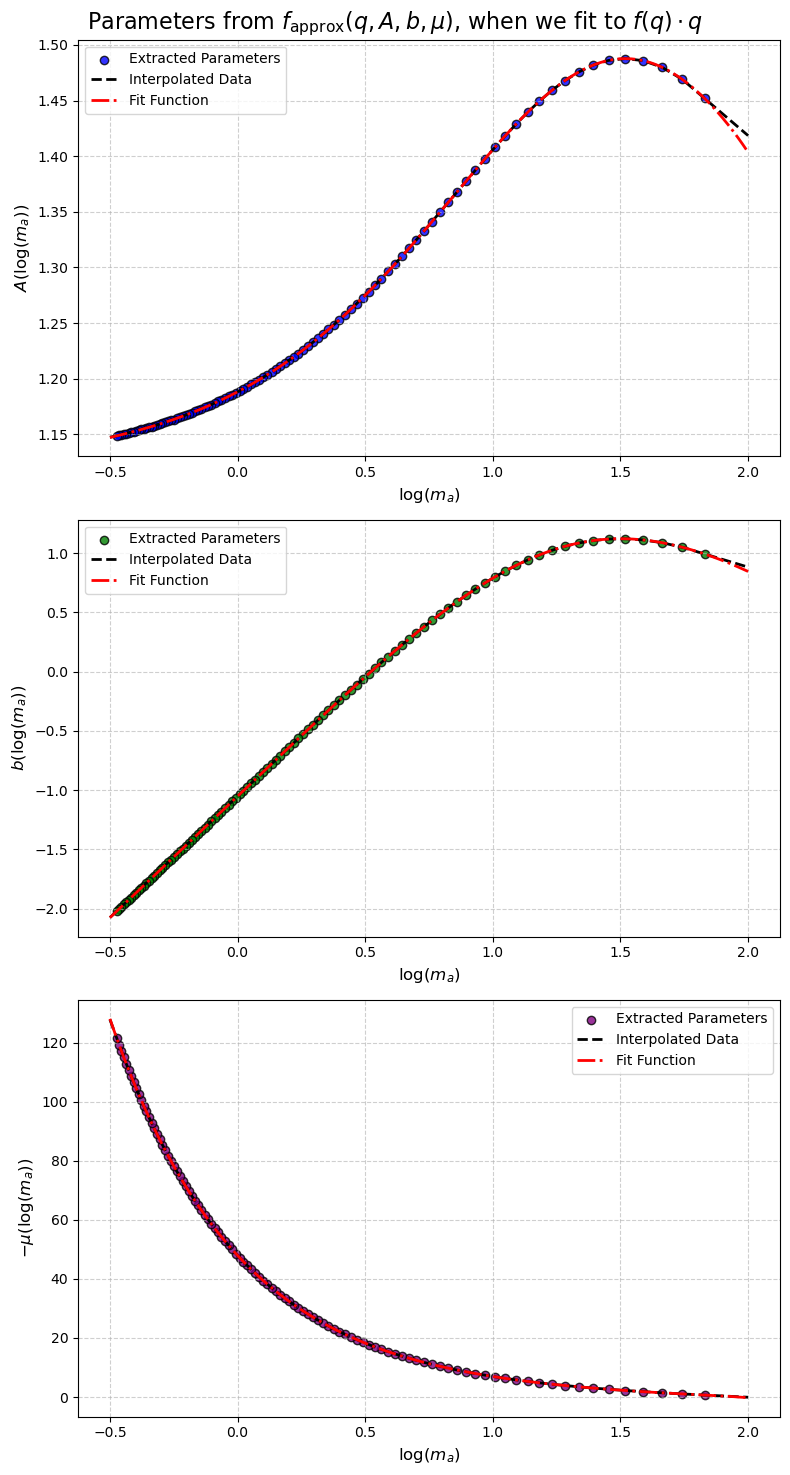

In [11]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$-\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(log_m_arr_input, points_param[i],
                color=colors[i], marker='o', edgecolors='black',
                alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    ax.plot(log_m_arr_set, interpolated_param[i],
             linestyle='--', linewidth=2, color='black',
             label='Interpolated Data')


    # Plot fitted function for the parameter
    ax.plot(log_m_arr_set, 
            parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                           log_m_arr_set,
                                                           "test_polynomial"),  # test_polynomial, test_fit
             linestyle='-.', linewidth=2, color='red',
             label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)
    
# Adjust layout
plt.tight_layout()
plt.show()

## Distribution: $f(q)$

It does work for this process but still we can notice a more profound difference than other distribution.

In [12]:
# --- DISTRIBUTION: f(q) ---
distribution = "f(q)"
parameterDependence.fit_all_distributions(dist=distribution)

# Set bounds for log(m_a)

log_m_start = -0.50  # -9.21, -4.0
log_m_end = 2.00     # 6.90, 3.5
log_m_arr_set = np.linspace(log_m_start, log_m_end, 500)  # Log(m_a) values for testing

# --- Interpolation ---
interpolated_A_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="A")(log_m_arr_set)
interpolated_b_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="b")(log_m_arr_set)
interpolated_mu_value = parameterDependence.get_interpolated_function(dist=distribution, parameter="mu")(log_m_arr_set)

# --- Base Data ---
m_arr_input = parameterDependence.get_axion_masses()
log_m_arr_input = np.log(m_arr_input)
fit_parameter = parameterDependence.get_fit_parameters(dist=distribution)

# --- Function Fitting: A(log(m_a)), b(log(m_a)), and μ(log(m_a)) ---
# polynomial
parameterDependence.compute_polynomial_fit(dist=distribution)

# function fit
# parameterDependence.switch_fitting_function("A", "piecewise")
# parameterDependence.switch_fitting_function("b", "b_function")
# parameterDependence.switch_fitting_function("mu", "exp_decay")
# parameterDependence.compute_functional_fit(dist=distribution)

Polynomial fit coefficients for A: [ 0.01537235 -0.11056959  0.30740165 -0.39195831  0.17857262  0.06390287
 -0.1073094   0.02845134  0.109664    0.20517718  0.24230882  2.14794233]
Polynomial fit coefficients for b: [ 0.04661993 -0.33475039  0.93032351 -1.20245944  0.59561359  0.17756731
 -0.33527686 -0.00430566  0.04957345  0.13914609  2.22243229  2.51553607]
Polynomial fit coefficients for μ: [  -0.22059189    1.64636633   -4.82323036    6.84230346   -5.02159022
    5.42158192  -19.00497345   52.53369093 -106.1221709   158.64821298
 -158.83724621   81.78031452]


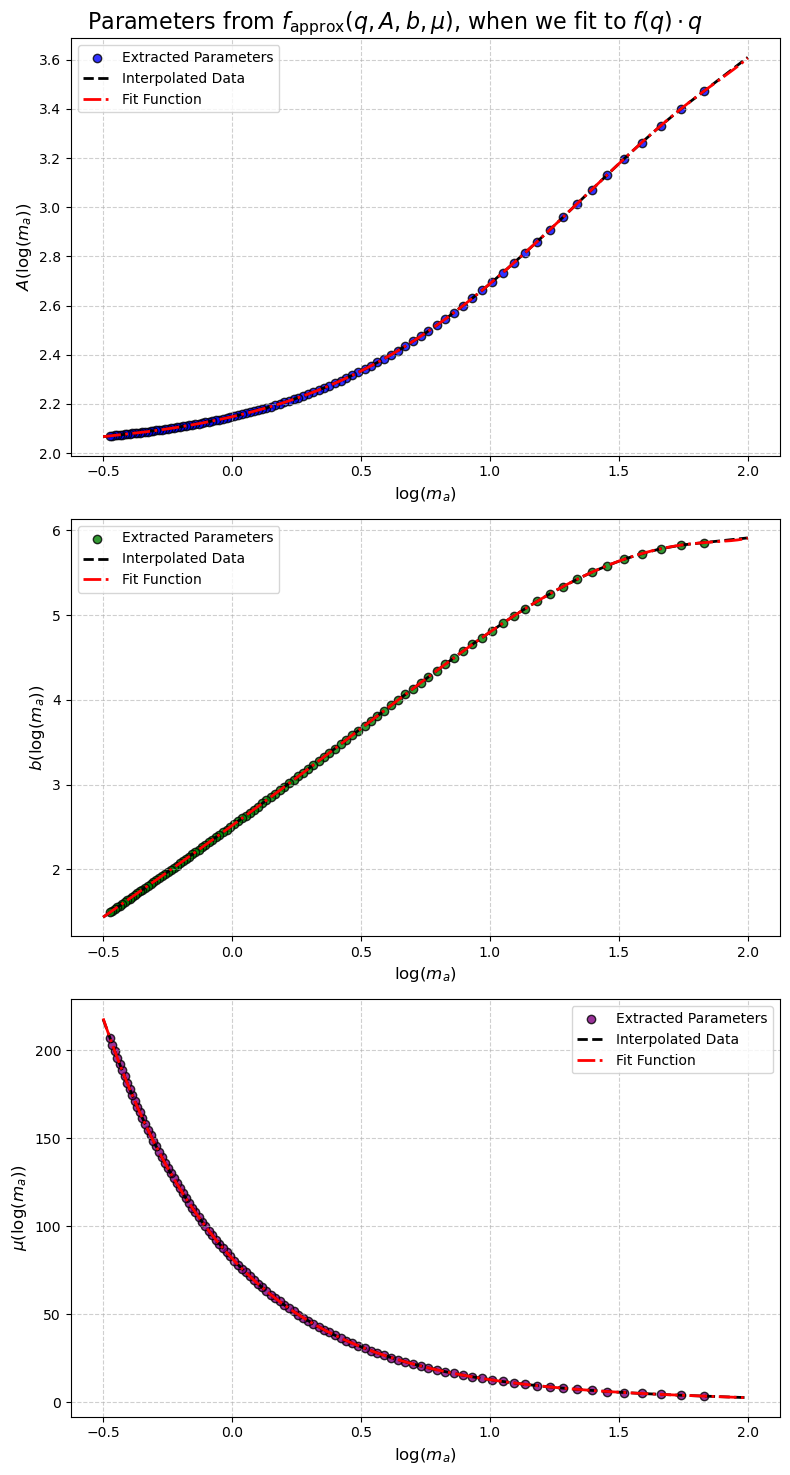

In [13]:
# Take all data in lists
name_of_parameters = ["A", "b", "mu"]
interpolated_param = [interpolated_A_value, interpolated_b_value, interpolated_mu_value]
points_param = [fit_parameter['A'], fit_parameter['b'], fit_parameter['mu']]
titles = [r"$A(\log(m_{a}))$", r"$b(\log(m_{a}))$", r"$\mu(\log(m_{a}))$"]

colors = ['blue', 'green', 'purple']  # Different colors for better distinction


# Set up figure with 2x2 subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 15))
fig.suptitle(r"Parameters from $f_{\mathrm{approx}}(q,A,b,\mu)$, when we fit to $f(q)\cdot q$", fontsize=16)

# Loop through subplots
for i, ax in enumerate(axes.flat):
    # Plot input data points
    ax.scatter(log_m_arr_input, points_param[i],
                color=colors[i], marker='o', edgecolors='black',
                alpha=0.8, label='Extracted Parameters')

    # Plot interpolation of extracted values
    ax.plot(log_m_arr_set, interpolated_param[i],
             linestyle='--', linewidth=2, color='black',
             label='Interpolated Data')


    # Plot fitted function for the parameter
    ax.plot(log_m_arr_set, 
            parameterDependence.get_fitted_parameter_value(name_of_parameters[i],
                                                           log_m_arr_set,
                                                           "test_polynomial"),  # test_polynomial, test_fit
             linestyle='-.', linewidth=2, color='red',
             label='Fit Function')
    
    # Labels and title
    ax.set_xlabel(r'$\log(m_{a})$', fontsize=12)
    ax.set_ylabel(titles[i], fontsize=12)
    # ax.set_title(titles[i], fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()